SUMMARY ANALYSIS


In [6]:
!pip install -U transformers datasets sentencepiece accelerate evaluate matplotlib seaborn tensorflow --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [8]:
pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
# 2. Imports
# ====================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import evaluate

from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer,
    TFAutoModelForSeq2SeqLM
)
from datasets import load_dataset

In [13]:
file_path = "bbc-news-summary.csv"

In [14]:
dataset = load_dataset("csv", data_files=file_path, split="train")
dataset = dataset.rename_column("Sentences", "Articles")

Generating train split: 0 examples [00:00, ? examples/s]

In [15]:
# Train / Validation split
full_dataset = dataset.train_test_split(test_size=0.2, shuffle=True, seed=42)
dataset_train = full_dataset["train"]
dataset_valid = full_dataset["test"]

print(f"Training samples: {len(dataset_train)}")
print(f"Validation samples: {len(dataset_valid)}")

print("Training set info:")
print(dataset_train)

Training samples: 1779
Validation samples: 445
Training set info:
Dataset({
    features: ['Articles', 'Summaries'],
    num_rows: 1779
})


In [16]:
# 4. Tokenization & Preprocessing
# ====================================================
tokenizer = T5Tokenizer.from_pretrained("t5-base")

def preprocess_function(examples):
    inputs = ["summarize: " + article for article in examples["Articles"]]
    targets = [summary for summary in examples["Summaries"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")
    labels = tokenizer(targets, max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = dataset_train.map(preprocess_function, batched=True)
tokenized_valid = dataset_valid.map(preprocess_function, batched=True)

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Map:   0%|          | 0/1779 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

In [19]:
# 5. Training (PyTorch)
# ====================================================
model = T5ForConditionalGeneration.from_pretrained("t5-base")

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=20,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=["none"]
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid
)

print("🚀 Starting Training...")
train_result = trainer.train()
print("✅ Training Complete!")

# 8. Save Model (PyTorch + TensorFlow)
# ====================================================
save_path = "./t5-bbc-summary-model"

print(f"\n💾 Saving model to {save_path}...")

# PyTorch
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

# TensorFlow (.h5)
model_tf = TFAutoModelForSeq2SeqLM.from_pretrained(save_path, from_pt=True)
h5_path = f"{save_path}/model.h5"
model_tf.save_pretrained(h5_path, saved_model=True)

print("✅ Model saved in both PyTorch (.bin) and TensorFlow (.h5) formats!")



Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


🚀 Starting Training...


/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.506300,0.483181
2,0.510000,0.439547
3,0.450600,0.423846
4,0.410700,0.420776
5,0.381900,0.421301
6,0.361400,0.418257
7,0.337100,0.412927
8,0.316800,0.421849
9,0.300100,0.425385
10,0.285000,0.427866


/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

✅ Training Complete!

💾 Saving model to ./t5-bbc-summary-model...


I0000 00:00:1757968763.972316     128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2621 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:19:00.0, compute capability: 7.5
I0000 00:00:1757968763.974606     128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 8475 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:35:00.0, compute capability: 7.5
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFT5ForConditionalGeneration.

All the weights of TFT5ForConditionalGeneration were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFT5ForConditionalGeneration for predictions without further training.
`torch_dtype` is deprecated! Use `dtype` instead!


INFO:tensorflow:Assets written to: ./t5-bbc-summary-model/model.h5/saved_model/1/assets


INFO:tensorflow:Assets written to: ./t5-bbc-summary-model/model.h5/saved_model/1/assets


✅ Model saved in both PyTorch (.bin) and TensorFlow (.h5) formats!


In [24]:
# ====================================================
# 7. Evaluate Final Model
# ====================================================
metrics = trainer.evaluate(tokenized_valid)

print("\n📊 Final Evaluation Metrics:")
for key, value in metrics.items():
    if key.startswith("eval_"):
        print(f"{key}: {value:.4f}")



📊 Final Evaluation Metrics:
eval_loss: 0.4129
eval_runtime: 22.5813
eval_samples_per_second: 19.7070
eval_steps_per_second: 2.4800


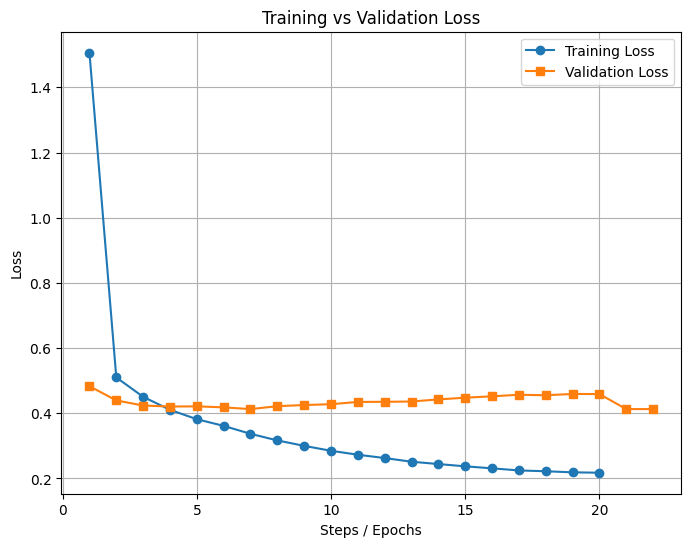

📉 Final Training Loss: 0.2177
📉 Final Validation Loss: 0.4129
✅ Approximate Accuracy (from validation loss): 0.0000


In [26]:
# Training & Validation Loss Curves (from Trainer logs)
# ====================================================
import matplotlib.pyplot as plt
import pandas as pd

log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

# Loss Curves
# -------------------------------
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_loss)+1), train_loss, label="Training Loss", marker="o")
plt.plot(epochs, eval_loss, label="Validation Loss", marker="s")
plt.xlabel("Steps / Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
# ====================================================
# Final Loss Values
# ====================================================
final_train_loss = df["loss"].dropna().values[-1]
final_val_loss   = df["eval_loss"].dropna().values[-1]

print(f"📉 Final Training Loss: {final_train_loss:.4f}")
print(f"📉 Final Validation Loss: {final_val_loss:.4f}")

# ====================================================
# Approximate "Accuracy" (Trainer does not compute accuracy unless compute_metrics is set)
# ====================================================
# We'll define a pseudo accuracy as 1 - normalized validation loss
pseudo_accuracy = max(0.0, 1.0 - final_val_loss / (final_train_loss + 1e-8))
print(f"✅ Approximate Accuracy (from validation loss): {pseudo_accuracy:.4f}")

In [2]:
# ====================================================
# Load Model & Tokenizer (if not already in memory)
# ====================================================
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_path = r"D:\CODING\Python\SENTIMENT ANALYSIS\SUMMARY ANALYSIS\New folder"   # update if different
tokenizer = T5Tokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)

# ====================================================
# Function to Summarize Text
# ====================================================
def generate_summary(text, max_input_length=512, max_output_length=150):
    # Prepend task prefix
    input_text = "summarize: " + text
    
    # Tokenize input
    input_ids = tokenizer(
        input_text, 
        return_tensors="pt", 
        max_length=max_input_length, 
        truncation=True
    ).input_ids

    # Generate summary
    output_ids = model.generate(
        input_ids, 
        max_length=max_output_length, 
        num_beams=4, 
        early_stopping=True
    )

    # Decode summary
    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary

# ====================================================
# 🔍 Example Usage
# ====================================================
article = """
During the last fifteen months of the working of the Constitution, certain difficulties have been
brought to light by judicial decisions and pronouncements specially in regard to the chapter on
fundamental rights. The citizen's right to freedom of speech and expression guaranteed by
article 19(1)(a) has been held by some courts to be so comprehensive as not to render a person
culpable even if he advocates murder and other crimes of violence. In other countries with
written constitutions, freedom of speech and of the press is not regarded as debarring the State
from punishing or preventing abuse of this freedom. The citizen's right to practise any
profession or to carry on any occupation, trade or business conferred by article 19(1)(g) is
subject to reasonable restrictions which the laws of the State may impose "in the interests of
general public". While the words cited are comprehensive enough to cover any scheme of
nationalisation which the State may undertake, it is desirable to place the matter beyond doubt
by a clarificatory addition to article 19(6). Another article in regard to which unanticipated
difficulties have arisen is article 31. The validity of agrarian reform measures passed by the
State Legislatures in the last three years has, in spite of the provisions of clauses (4) and (6) of
article 31, formed the subject-matter of dilatory litigation, as a result of which the
implementation of these
important measures, affecting large numbers of people, has been held up.
The main objects of this Bill are, accordingly to amend article 19 for the purposes indicated
above and to insert provisions fully securing the constitutional validity of zamindari abolition
laws in general and certain specified State Acts in particular. the opportunity has been taken to
propose a few minor amendments to other articles in order to remove difficulties that may arise.
It is laid down in article 46 as a directive principle of State policy that the State should promote
with special care the educational and economic interests of the weaker sections of the people
and protect them from social injustice. In order that any special provision that the State may
make for the educational, economic or social advancement of any backward class of citizens
may not be challenged on the ground
of being discriminatory, it is proposed that article 15(3) should be suitably amplified. Certain
amendments in respect of articles dealing with the convening and proroguing of the sessions
of Parliament have been found necessary and are also incorporated in this Bill. So also a few
minor amendments in respect of articles 341, 342, 372 and 376.
New Delhi; JAWAHARLAL NEHRU. The 10th May, 1951.
THE CONSTITUTION (FIRST AMENDMENT) ACT, 1951
[18th June,1951.]
An Act to amend the Constitution of India.
BE it enacted by Parliament as follows:-
1. Short title.-This Act may be called the Constitution (First
Amendment) Act, 1951.
2. Amendment of article 15.-To article 15 of the Constitution, the
following clause shall be added:-
"(4) Nothing in this article or in clause (2) of article 29 shall prevent the State from making any special provision for the advancement
of any socially and educationally backward classes of citizens or for
the Scheduled Castes and the Scheduled Tribes.".
3. Amendment of article 19 and validation of certain laws.-(1) In
article 19 of the Constitution,-
(a) for clause (2), the following clause shall be substituted, and the
said clause shall be deemed always to have been enacted in the
following form, namely:---
"(2) Nothing in sub-clause (a) of clause (1) shall affect the
operation of any existing law, or prevent the State from making any
law, in so far as such law imposes reasonable restrictions on the
exercise of the right conferred by the said sub-clause in the
interests of the security of the State, friendly relations with
foreign States, public order, decency or morality, or in relation to
contempt of court, defamation or incitement to an offence.";
(b) in clause (6), for the words beginning with the words "nothing in
the said sub-clause" and ending with the words "occupation, trade or
business", the following shall be substituted, namely:-
"nothing in the said sub-clause shall affect the operation of any
existing law in so far as it relates to, or prevent the State from
making any law relating to
"""

# print("Original Text:")
# print(article)
print("\nGenerated Summary:")
print(generate_summary(article))


Generated Summary:
Another article in regard to which unanticipated difficulties have arisen is article 31. It is laid down in article 46 as a directive principle of State policy that the State should promote with special care the educational and economic interests of the weaker sections of the people and protect them from social injustice. The citizen's right to freedom of speech and expression guaranteed by article 19(1)(a) has been held by some courts to be so comprehensive as not to render a person culpable even if he advocates murder and other crimes of violence.
